# Validation Graph Explorer

Use this notebook to locate a validation/test pickle dumped by `Trainer.run_validation` and view the stored predicted graphs in interactive 3D.

### Prerequisites
- Ensure your validation runs saved pickles under `outputs/.../validation/step_*.pkl`.
- Install the optional dependencies used here (if they are not already in your environment):
  ```bash
  pip install plotly ipywidgets
  ```
- Enable ipywidgets extensions in JupyterLab if prompted (e.g., `pip install jupyterlab_widgets`).

Run the cells below top-to-bottom, then use the dropdowns/sliders to pick a saved pickle, EMA beta, graph index, and depth cutoff.

In [5]:
from pathlib import Path
import pickle

import networkx as nx
import numpy as np
import plotly.graph_objects as go
from ipywidgets import Dropdown, IntSlider, HTML, Output, VBox
from IPython.display import display, clear_output

print("Imports ready.")

Imports ready.


In [6]:
# Root directory that Hydra/Trainer writes into. Adjust if you keep outputs elsewhere.
OUTPUT_ROOT = Path('../full_run_outs').resolve()

available_pickles = sorted(OUTPUT_ROOT.glob('*.pkl'))
if not available_pickles:
    raise FileNotFoundError(f'No validation pickles found under {OUTPUT_ROOT}. Run validation first.')

print(f'Discovered {len(available_pickles)} pickle file(s). Latest: {available_pickles[-1]}')

Discovered 38 pickle file(s). Latest: /Users/umer/Documents/dendrite_gen/full_run_outs/step_30001.pkl


In [7]:
def load_validation_pickle(path: Path):
    path = Path(path)
    with open(path, 'rb') as f:
        data = pickle.load(f)
    return data


def build_plotly_figure(graph: nx.Graph, title: str):
    positions = {}
    for node in graph.nodes():
        pos = np.asarray(graph.nodes[node].get('pos', np.zeros(3)), dtype=float).flatten()
        if pos.size < 3:
            pos = np.pad(pos, (0, 3 - pos.size), constant_values=0.0)
        positions[node] = pos[:3]

    node_x, node_y, node_z, node_labels = [], [], [], []
    for node, pos in positions.items():
        node_x.append(pos[0])
        node_y.append(pos[1])
        node_z.append(pos[2])
        node_labels.append(str(node))

    edge_x, edge_y, edge_z = [], [], []
    for u, v in graph.edges():
        x0, y0, z0 = positions[u]
        x1, y1, z1 = positions[v]
        edge_x.extend([x0, x1, None])
        edge_y.extend([y0, y1, None])
        edge_z.extend([z0, z1, None])

    fig = go.Figure()
    if edge_x:
        fig.add_trace(
            go.Scatter3d(
                x=edge_x,
                y=edge_y,
                z=edge_z,
                mode='lines',
                line=dict(color='lightgray', width=2),
                hoverinfo='skip',
                name='edges',
            )
        )

    fig.add_trace(
        go.Scatter3d(
            x=node_x,
            y=node_y,
            z=node_z,
            mode='markers',
            marker=dict(size=6, color='royalblue', line=dict(color='black', width=0.5)),
            text=node_labels,
            name='nodes',
        )
    )

    fig.update_layout(
        title=title,
        scene=dict(
            xaxis_title='x',
            yaxis_title='y',
            zaxis_title='z',
            aspectmode='data',
        ),
        margin=dict(l=0, r=0, t=40, b=0),
    )
    return fig


def pretty_label(path: Path):
    path = Path(path)
    try:
        rel = path.relative_to(OUTPUT_ROOT)
        return str(rel)
    except ValueError:
        return str(path)


def compute_node_depths(graph: nx.Graph):
    nodes = list(graph.nodes())
    if not nodes:
        return {}, 0, None
    # Use node 0 as canonical root (matches generation); fallback to first available node.
    root = 0 if 0 in graph else nodes[0]
    lengths = nx.single_source_shortest_path_length(graph, root)
    if lengths:
        missing_depth = max(lengths.values()) + 1
    else:
        missing_depth = 0
    depths = {n: lengths.get(n, missing_depth) for n in nodes}
    max_depth = max(depths.values(), default=0)
    return depths, max_depth, root

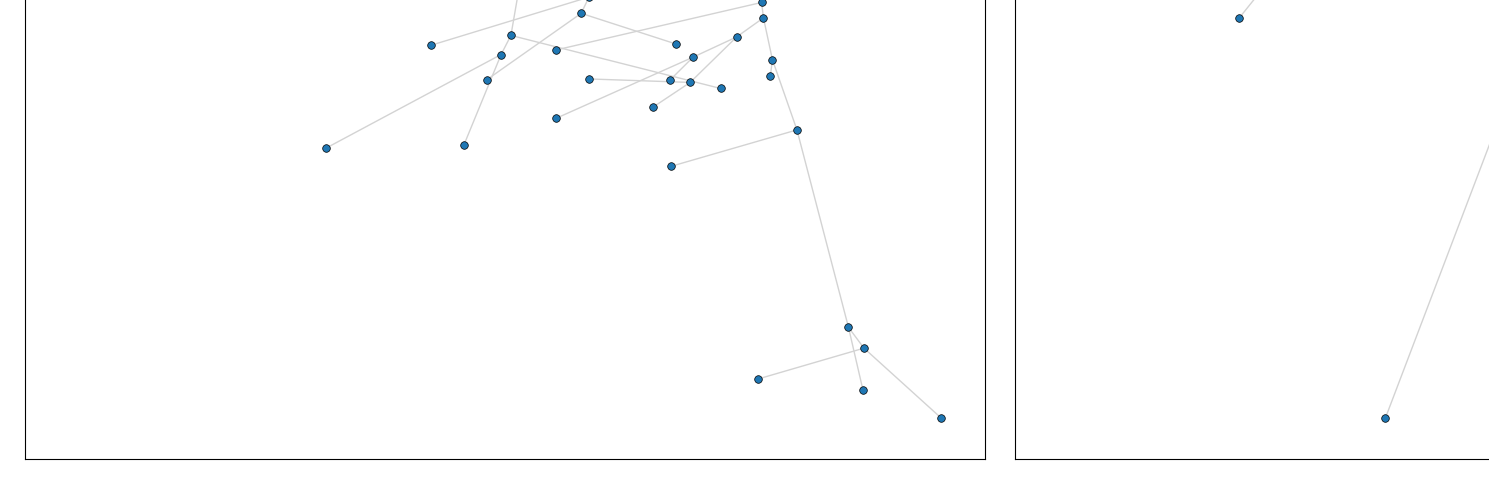

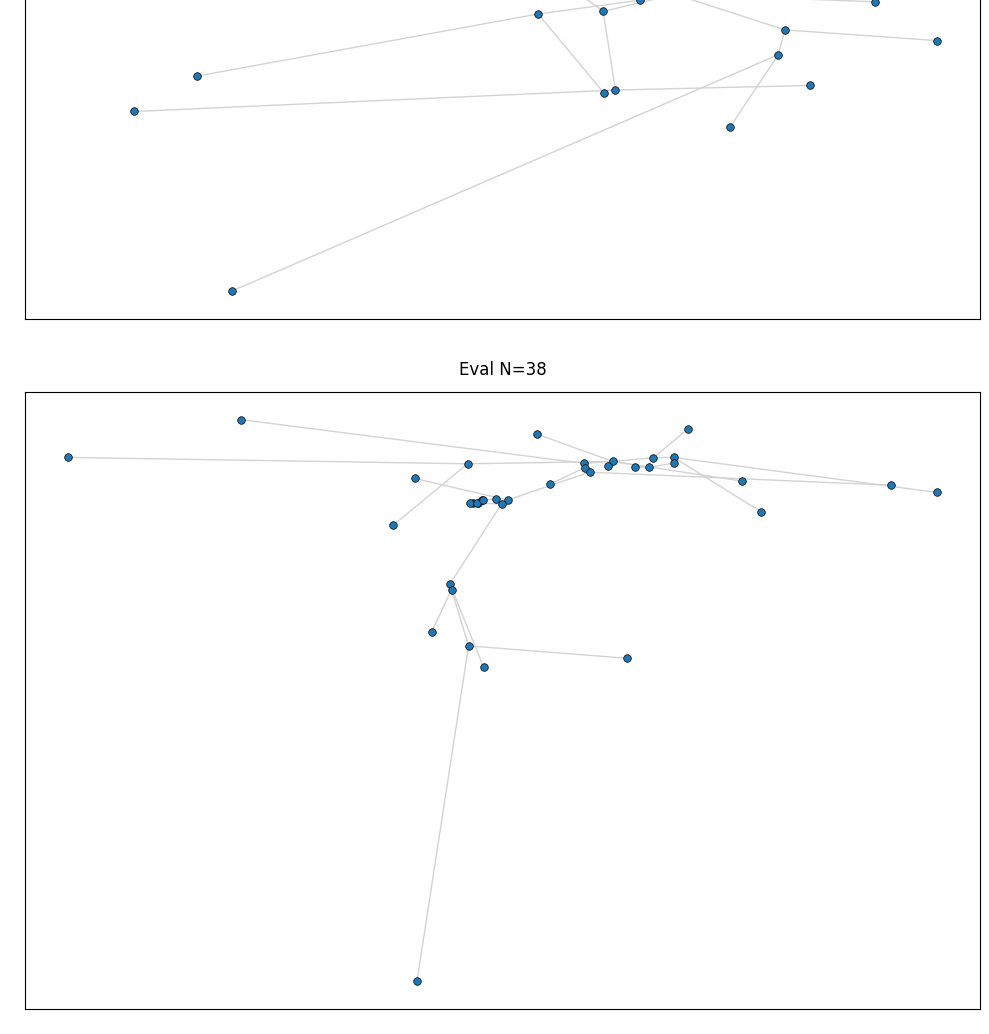

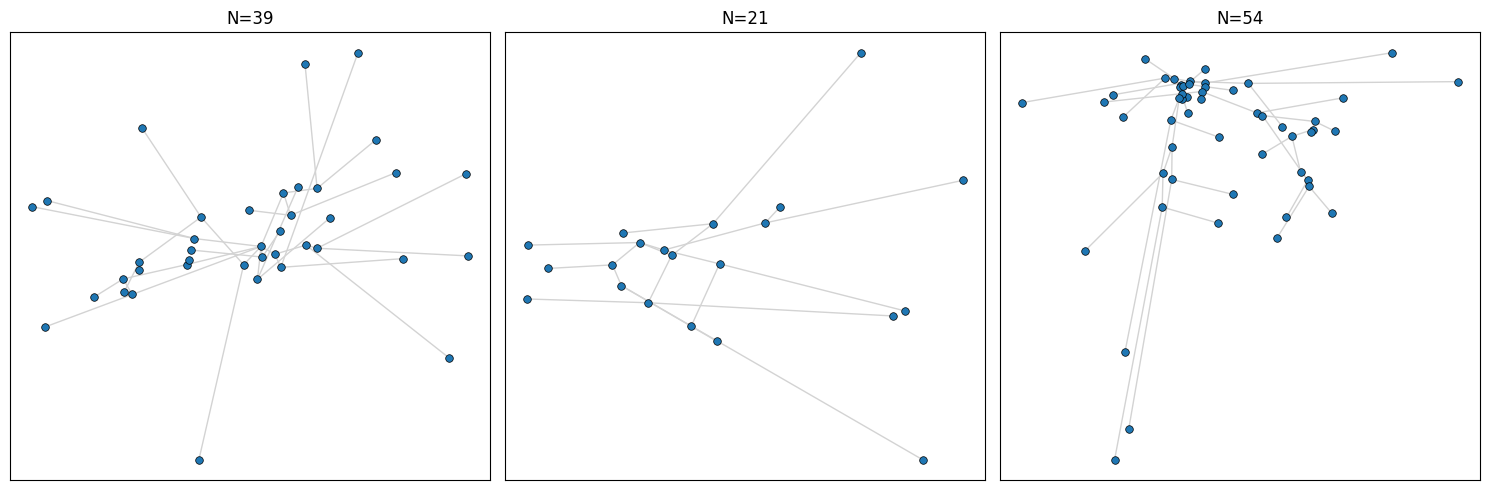

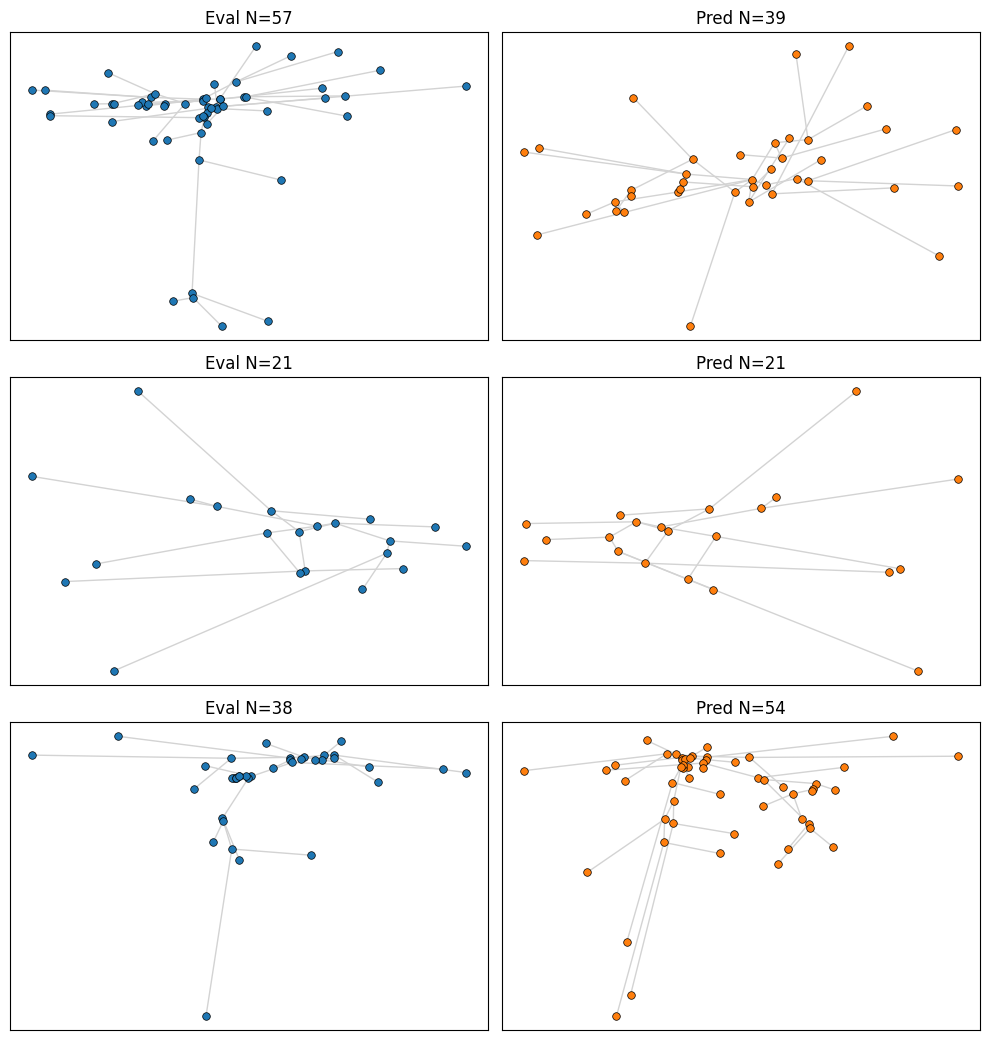

In [ ]:
# --- Interactive widgets ---
pickle_options = [(pretty_label(p), str(p)) for p in available_pickles]
file_dropdown = Dropdown(
    options=pickle_options,
    description='Result',
    value=pickle_options[-1][1],
    layout=dict(width='70%'),
)
beta_dropdown = Dropdown(options=[], description='EMA beta', layout=dict(width='40%'))
graph_slider = IntSlider(
    value=0,
    min=0,
    max=0,
    step=1,
    description='Graph idx',
    continuous_update=False,
    layout=dict(width='60%'),
)
depth_slider = IntSlider(
    value=0,
    min=0,
    max=0,
    step=1,
    description='Depth',
    continuous_update=False,
    layout=dict(width='60%'),
    disabled=True,
)
status_html = HTML(value='Select a pickle to begin.')
plot_output = Output()

validation_payload = load_validation_pickle(file_dropdown.value)
current_depths = {}
current_max_depth = 0
current_root = None
suppress_graph_event = False
suppress_depth_event = False


def clear_depth_state():
    global current_depths, current_max_depth, current_root, suppress_depth_event
    current_depths = {}
    current_max_depth = 0
    current_root = None
    suppress_depth_event = True
    depth_slider.disabled = True
    depth_slider.max = 0
    depth_slider.value = 0
    depth_slider.description = 'Depth'
    suppress_depth_event = False


def set_graph_slider(value: int):
    global suppress_graph_event
    suppress_graph_event = True
    graph_slider.value = value
    suppress_graph_event = False


def set_depth_slider(value: int):
    global suppress_depth_event
    suppress_depth_event = True
    depth_slider.value = value
    suppress_depth_event = False


def refresh_beta_dropdown():
    clear_depth_state()
    betas = sorted(validation_payload.keys())
    if not betas:
        beta_dropdown.options = []
        beta_dropdown.value = None
        graph_slider.disabled = True
        status_html.value = 'Selected pickle contains no EMA entries.'
        with plot_output:
            clear_output(wait=True)
            print('No data to display for this pickle.')
        return
    beta_dropdown.options = betas
    if beta_dropdown.value not in betas:
        beta_dropdown.value = betas[0]
    refresh_graph_slider()


def refresh_graph_slider():
    beta_key = beta_dropdown.value
    graphs = validation_payload.get(beta_key, {}).get('pred_graphs', []) if beta_key else []
    has_graphs = len(graphs) > 0
    graph_slider.disabled = not has_graphs
    graph_slider.max = max(0, len(graphs) - 1)
    if graph_slider.value > graph_slider.max:
        set_graph_slider(graph_slider.max)
    if has_graphs:
        status_html.value = f'{len(graphs)} generated graph(s) available for {beta_key}.'
        set_graph_slider(graph_slider.max)
        update_plot(recompute_depth=True)
    else:
        clear_depth_state()
        status_html.value = f'No `pred_graphs` stored for {beta_key}.'
        with plot_output:
            clear_output(wait=True)
            print('No graphs to display for this beta selection.')


def update_plot(recompute_depth: bool):
    beta_key = beta_dropdown.value
    graphs = validation_payload.get(beta_key, {}).get('pred_graphs', []) if beta_key else []
    if not graphs:
        return
    idx = int(np.clip(graph_slider.value, 0, len(graphs) - 1))
    graph = graphs[idx]

    global current_depths, current_max_depth, current_root
    if recompute_depth or not current_depths:
        depths, max_depth, root = compute_node_depths(graph)
        current_depths = depths
        current_max_depth = max_depth
        current_root = root
        depth_slider.min = 0
        depth_slider.max = max_depth
        depth_slider.step = 1
        depth_slider.disabled = False
        depth_slider.description = f'Depth (root={root})' if root is not None else 'Depth'
        set_depth_slider(max_depth)

    depth_limit = depth_slider.value if not depth_slider.disabled else current_max_depth
    visible_nodes = [n for n, d in current_depths.items() if d <= depth_limit]

    if not visible_nodes:
        with plot_output:
            clear_output(wait=True)
            print('No nodes available at or above this depth. Move the slider to include more levels.')
        return

    subgraph = graph.subgraph(visible_nodes).copy()
    hidden_nodes = graph.number_of_nodes() - subgraph.number_of_nodes()
    title = f'{beta_key} | Graph {idx} | nodes={subgraph.number_of_nodes()} (hidden {hidden_nodes})'
    fig = build_plotly_figure(subgraph, title)
    with plot_output:
        clear_output(wait=True)
        display(fig)
    extra = f'Hidden nodes beyond depth {depth_limit}: {hidden_nodes}' if hidden_nodes else 'All nodes visible.'
    status_html.value = f'{len(graphs)} generated graph(s) available for {beta_key}. {extra}'


def handle_file_change(change):
    global validation_payload
    new_path = change.get('new')
    if not new_path:
        return
    validation_payload = load_validation_pickle(new_path)
    refresh_beta_dropdown()


def handle_beta_change(change):
    if change['new'] is None:
        return
    refresh_graph_slider()


def handle_graph_change(change):
    if suppress_graph_event:
        return
    update_plot(recompute_depth=True)


def handle_depth_change(change):
    if suppress_depth_event:
        return
    update_plot(recompute_depth=False)


file_dropdown.observe(handle_file_change, names='value')
beta_dropdown.observe(handle_beta_change, names='value')
graph_slider.observe(handle_graph_change, names='value')
depth_slider.observe(handle_depth_change, names='value')

refresh_beta_dropdown()
display(VBox([file_dropdown, beta_dropdown, graph_slider, depth_slider, status_html, plot_output]))
update_plot(recompute_depth=True)